In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

# Find the uploaded files

base = '/content/drive/Shareddrives'

for root, dirs, files in os.walk(base):
    for f in files:
        if f.endswith('.zip'):
            print(os.path.join(root, f))

/content/drive/Shareddrives/depth_estimators/waymo_open/output/depth.zip
/content/drive/Shareddrives/depth_estimators/waymo_open/output/images.zip
/content/drive/Shareddrives/depth_estimators/Monodepth/heatmaps.zip
/content/drive/Shareddrives/depth_estimators/Raw Datasets/raw_files.zip
/content/drive/Shareddrives/depth_estimators/Raw Datasets/processed_data/individual_files_training_segment-10017090168044687777_6380_000_6400_000_with_camera_labels.zip
/content/drive/Shareddrives/depth_estimators/Raw Datasets/processed_data/individual_files_training_segment-10023947602400723454_1120_000_1140_000_with_camera_labels.zip
/content/drive/Shareddrives/depth_estimators/Raw Datasets/processed_data/individual_files_training_segment-1005081002024129653_5313_150_5333_150_with_camera_labels.zip
/content/drive/Shareddrives/depth_estimators/Raw Datasets/processed_data/individual_files_training_segment-10061305430875486848_1080_000_1100_000_with_camera_labels.zip
/content/drive/Shareddrives/depth_esti

In [8]:
import zipfile
import numpy as np
import os

# Paths
pred_zip = '/content/drive/Shareddrives/depth_estimators/ECOCar Depth/pred_test.zip'

gt_zip = '/content/drive/Shareddrives/depth_estimators/ECOCar Depth/gt_test.zip'

# Extract to local Colab storage
os.makedirs('/content/pred', exist_ok=True)

os.makedirs('/content/gt', exist_ok=True)


with zipfile.ZipFile(pred_zip, 'r') as z:
    z.extractall('/content/pred')

    print("Pred files:", z.namelist())


with zipfile.ZipFile(gt_zip, 'r') as z:
    z.extractall('/content/gt')

    print("GT files:", z.namelist())

Extracting pred...
Pred files: ['segment-10689101165701914459_2072_300_2092_300_with_camera_labels_depths.npy', 'segment-10689101165701914459_2072_300_2092_300_with_camera_labels_stems.npy']
Extracting gt...
GT files: ['all_depths.npy', 'all_depths_stems.npy']


In [12]:
def align_and_rmse(pred, gt):

    valid = ~np.isnan(gt)
    if valid.sum() < 10:
        return None  # skip frames with too few valid points

    gt_valid = gt[valid]

    pred_valid = pred[valid]

    # Least squares: solve for a, b in a*pred + b = gt
    A = np.stack([pred_valid, np.ones_like(pred_valid)], axis=1)

    result = np.linalg.lstsq(A, gt_valid, rcond=None)

    a, b = result[0]

    # Align prediction
    pred_aligned = a * pred + b

    # RMSE on valid pixels only
    diff = pred_aligned[valid] - gt_valid

    rmse = np.sqrt(np.mean(diff ** 2))

    return rmse


# Test on the first frame
pred_depths = np.load('/content/pred/segment-10689101165701914459_2072_300_2092_300_with_camera_labels_depths.npy', mmap_mode='r')

gt_depths   = np.load('/content/gt/all_depths.npy', mmap_mode='r')

gt_stems    = np.load('/content/gt/all_depths_stems.npy', allow_pickle=True)

pred_stems  = np.load('/content/pred/segment-10689101165701914459_2072_300_2092_300_with_camera_labels_stems.npy', allow_pickle=True)


print("GT stems sample:  ", gt_stems[:3])

print("Pred stems sample:", pred_stems[:3])

rmse = align_and_rmse(pred_depths[0], gt_depths[0])

print(f"\nFrame 0 RMSE: {rmse:.4f} meters")

GT stems sample:   ['frame_00000' 'frame_00001' 'frame_00002']
Pred stems sample: ['frame_00000' 'frame_00001' 'frame_00002']

Frame 0 RMSE: 9.7812 meters


In [14]:
from tqdm import tqdm

def segment_rmse(pred_depths, gt_depths, pred_stems, gt_stems):

    # Build lookup for gt by stem name

    gt_lookup = {stem: i for i, stem in enumerate(gt_stems)}

    rmse_list = []
    for i, stem in enumerate(pred_stems):
        if stem not in gt_lookup:
            continue  # skip unmatched frames

        j = gt_lookup[stem]

        rmse = align_and_rmse(pred_depths[i], gt_depths[j])

        if rmse is not None:
            rmse_list.append(rmse)

    return np.mean(rmse_list), len(rmse_list)


mean_rmse, n_frames = segment_rmse(pred_depths, gt_depths, pred_stems, gt_stems)

print(f"Segment mean RMSE: {mean_rmse:.4f} meters over {n_frames} frames")

Segment mean RMSE: 8.2334 meters over 198 frames


In [16]:
import pandas as pd

csv_path = '/content/drive/Shareddrives/depth_estimators/ECOCar Depth/rmse_results.csv'
df = pd.read_csv(csv_path)

print(df.head())

print(f"\nTotal segments: {len(df)}")

print(f"Seen segments:   {len(df[df.split=='seen'])}")

print(f"Unseen segments: {len(df[df.split=='unseen'])}")


print(f"\nSeen   RMSE: {df[df.split=='seen']['mean_rmse'].mean():.4f} m")
print(f"Unseen RMSE: {df[df.split=='unseen']['mean_rmse'].mean():.4f} m")

                                             segment   split  mean_rmse  \
0  segment-10084636266401282188_1120_000_1140_000...    seen   8.105951   
1  segment-10149575340910243572_2720_000_2740_000...    seen   8.602984   
2  segment-10161761842905385678_760_000_780_000_w...    seen   8.140843   
3  segment-10203656353524179475_7625_000_7645_000...  unseen   8.956742   
4  segment-1024360143612057520_3580_000_3600_000_...    seen   8.640332   

   n_frames  
0       199  
1       199  
2       198  
3       198  
4       199  

Total segments: 350
Seen segments:   244
Unseen segments: 106

Seen   RMSE: 9.0612 m
Unseen RMSE: 8.9314 m


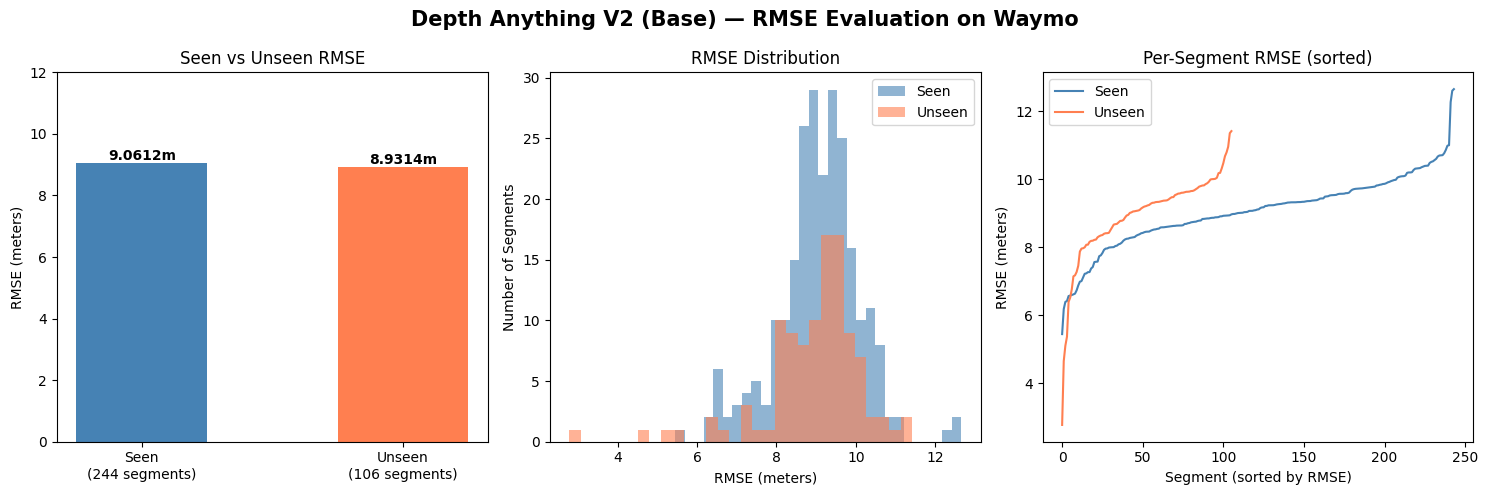

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle('Depth Anything V2 (Base) — RMSE Evaluation on Waymo', fontsize=15, fontweight='bold')

# Seen vs Unseen bar chart

seen_rmse   = df[df.split=='seen']['mean_rmse'].mean()
unseen_rmse = df[df.split=='unseen']['mean_rmse'].mean()
axes[0].bar(['Seen\n(244 segments)', 'Unseen\n(106 segments)'],
            [seen_rmse, unseen_rmse],
            color=['steelblue', 'coral'], width=0.5)

axes[0].set_ylabel('RMSE (meters)')

axes[0].set_title('Seen vs Unseen RMSE')

axes[0].set_ylim(0, 12)

for i, v in enumerate([seen_rmse, unseen_rmse]):
    axes[0].text(i, v + 0.1, f'{v:.4f}m', ha='center', fontweight='bold')

# RMSE distribution histogram
axes[1].hist(df[df.split=='seen']['mean_rmse'], bins=30, alpha=0.6, label='Seen', color='steelblue')
axes[1].hist(df[df.split=='unseen']['mean_rmse'], bins=30, alpha=0.6, label='Unseen', color='coral')

axes[1].set_xlabel('RMSE (meters)')
axes[1].set_ylabel('Number of Segments')

axes[1].set_title('RMSE Distribution')
axes[1].legend()

# RMSE per segment
seen_vals   = sorted(df[df.split=='seen']['mean_rmse'].values)
unseen_vals = sorted(df[df.split=='unseen']['mean_rmse'].values)

axes[2].plot(seen_vals,   label='Seen',   color='steelblue')
axes[2].plot(unseen_vals, label='Unseen', color='coral')

axes[2].set_xlabel('Segment (sorted by RMSE)')
axes[2].set_ylabel('RMSE (meters)')

axes[2].set_title('Per-Segment RMSE (sorted)')
axes[2].legend()

plt.tight_layout()

plt.savefig('/content/drive/Shareddrives/depth_estimators/ECOCar Depth/rmse_plot.png', dpi=150, bbox_inches='tight')

plt.show()
